In [2]:
# 2.1.2 Interquartile Range (IQR)

import pandas as pd
import numpy as np

data = pd.Series(np.random.normal(size=10_000))
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1
iqr_lower_limit = q1 - (2.2 * iqr)
iqr_upper_limit = q3 + (2.2 * iqr)

print(iqr_lower_limit)
print(iqr_upper_limit)

-3.6151262893014824
3.6244407635887623


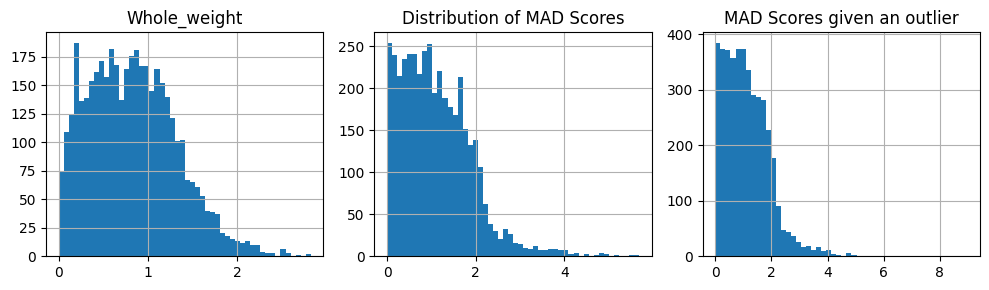

In [3]:
# Listing 2.1 Calculating the median absolute deviation

import pandas as pd
import numpy as np
import statistics
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

def calc_MAD(data):
    median = statistics.median(data)
    deviations = [abs(x - median) for x in data]
    median_deviation = statistics.median(deviations)
    mad_scores = [abs(x - median) / median_deviation for x in data]
    return mad_scores

data = fetch_openml("abalone", version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

pd.Series(data['Whole_weight']).hist(bins=50, ax=ax[0])
ax[0].set_title("Whole_weight")

mad_scores = calc_MAD(data['Whole_weight'])
pd.Series(mad_scores).hist(bins=50, ax=ax[1])
ax[1].set_title("Distribution of MAD Scores")

mad_scores = calc_MAD(np.concatenate([data['Whole_weight'], [4.0]]))
pd.Series(mad_scores).hist(bins=50, ax=ax[2])
ax[2].set_title("MAD Scores given an outlier")

plt.tight_layout()
plt.show()

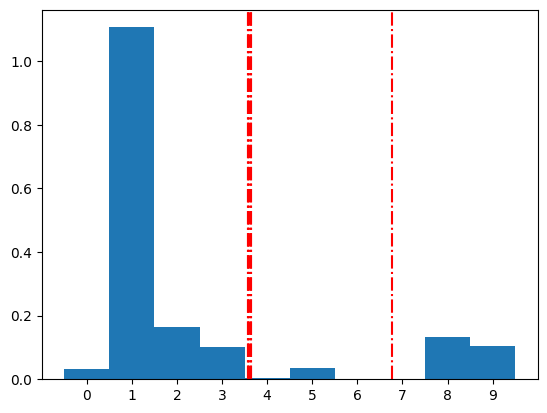

In [4]:
# Listing 2.2 Using histograms to identify outliers

import pandas as pd
from sklearn.datasets import fetch_openml
import statistics
import matplotlib.pyplot as plt

data = fetch_openml('segment', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)

histogram = pd.cut(data['hue-mean'], bins=10, retbins=True)[0]
counts = histogram.value_counts().sort_index()

rare_ranges = []
for v in counts.index:
    count = counts[v]
    if count < 10:
        rare_ranges.append(str(v))

rare_values = []
for i in range(len(data)):
    if str(histogram[i]) in rare_ranges:
        rare_values.append(data['hue-mean'][i])

fig, ax = plt.subplots()
plt.hist(data['hue-mean'], bins=10, density=True)
for rare_value in rare_values:
    ax.axvline(rare_value, color='red', linestyle='-.')
plt.xticks([statistics.mean([x.left, x.right]) for x in counts.index])
ax.set_xticklabels(range(10))
plt.show()

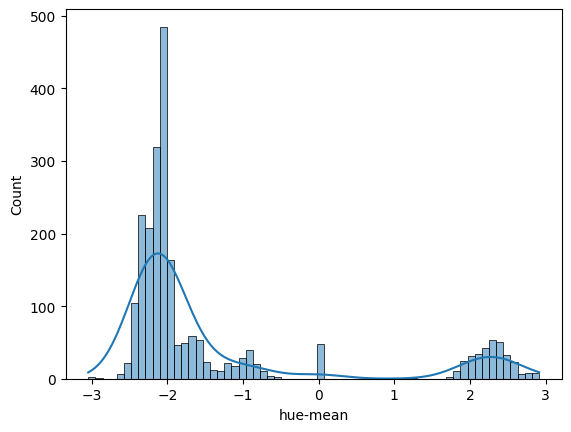

In [5]:
# Listing 2.3 Seaborn histplots with KDE enabled

import pandas as pd
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns

data = fetch_openml('segment', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)
sns.histplot(data['hue-mean'], kde=True)
plt.show()

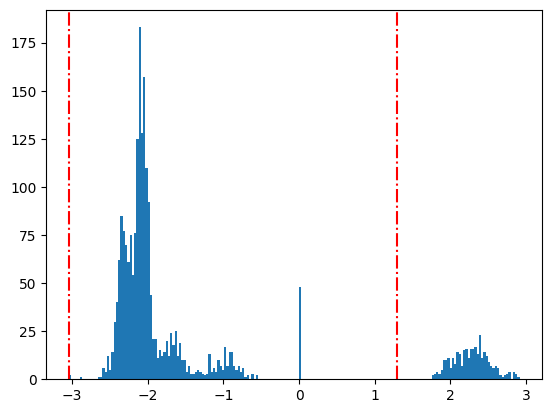

In [6]:
# Listing 2.4 Using KDE to identify outliers

import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt

data = fetch_openml('segment', version=1, parser='auto')
data = pd.DataFrame(data.data, columns=data.feature_names)

X = data['hue-mean'].values.reshape(-1,1)
kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(X)
kde_scores = pd.Series(kde.score_samples(X))

q1 = kde_scores.quantile(0.25)
q3 = kde_scores.quantile(0.75)
iqr = q3 - q1
threshold = q1 - (2.2 * iqr)
rare_values = [data['hue-mean'][x] for x in range(len(data))
               if kde_scores[x] < threshold]

fig, ax = plt.subplots()
plt.hist(data['hue-mean'], bins=200)
for rare_value in rare_values:
    ax.axvline(rare_value, color='red', linestyle='-.')
plt.show()